# Experiment: Will Adding Geometry Information Improve the Performance of TIC?
This notebook organizes the workflow to test whether incorporating geometry information into the TIC pipeline enhances pseudotime inference performance.

## Geometry Feature Mathematical Definitions

Below are the mathematical definitions for the geometry-based features extracted for each cell boundary polygon.

1. **Area**  
$$
A = \frac{1}{2} \left| \sum_{i=1}^{N} x_i y_{i+1} - y_i x_{i+1} \right|
$$

2. **Perimeter**  
$$
P = \sum_{i=1}^{N} \sqrt{ (x_{i+1} - x_i)^2 + (y_{i+1} - y_i)^2 }
$$

3. **Aspect Ratio**  
Let  
$$
w = \max(x) - \min(x), \quad h = \max(y) - \min(y)
$$  
Then  
$$
\mathrm{AspectRatio} = \frac{w}{h}
$$

4. **Compactness**  
$$
\mathrm{Compactness} = \frac{P^2}{A}
$$

5. **Centroid**  
$$
(\bar{x}, \bar{y}) = \left( \frac{1}{N} \sum_{i=1}^{N} x_i, \; \frac{1}{N} \sum_{i=1}^{N} y_i \right)
$$

The final geometry features vector for each cell is:
$$
\mathbf{f} = [A, P, \mathrm{AspectRatio}, \mathrm{Compactness}, \bar{x}, \bar{y}]
$$




## 1. Setup
Import required libraries and load the dataset. Make sure to set your OpenAI API key in `utils/config.py`.

In [16]:
from warnings import filterwarnings
filterwarnings('ignore')


In [17]:
from tic.data import load_xenium_dataset

# Load subset of Xenium FFPE human breast dataset with a mask
adata = load_xenium_dataset(
    name='xenium_kidney_cancer',
    normalize='size',
    include_mask=True
)
adata

Xenium dataset 'xenium_kidney_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer
2025-05-29 14:43:49,711 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_kidney_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer
2025-05-29 14:43:49,956 INFO Loaded cell boundaries: cell_boundaries.parquet
2025-05-29 14:43:49,956 | INFO     | tic.data.xenium.loader | Loaded cell boundaries: cell_boundaries.parquet
2025-05-29 14:43:50,046 INFO Loaded nucleus boundaries: nucleus_boundaries.parquet
2025-05-29 14:43:50,046 | INFO     | tic.data.xenium.loader | Loaded nucleus boundaries: nucleus_boundaries.parquet
2025-05-29 14:43:50,046 INFO Loaded xenium_kidney_cancer: 56510 cells * 541 genes.
2025-05-29 14:43:50,046 | INFO     | tic.data.xenium.loader | Loaded xenium_kidney_cancer: 56510 cells * 541 genes.


AnnData object with n_obs × n_vars = 56510 × 541
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cell_boundaries', 'tissue_id', 'data_level'
    obsm: 'spatial'

### explore the dataset: cell geometry/shape

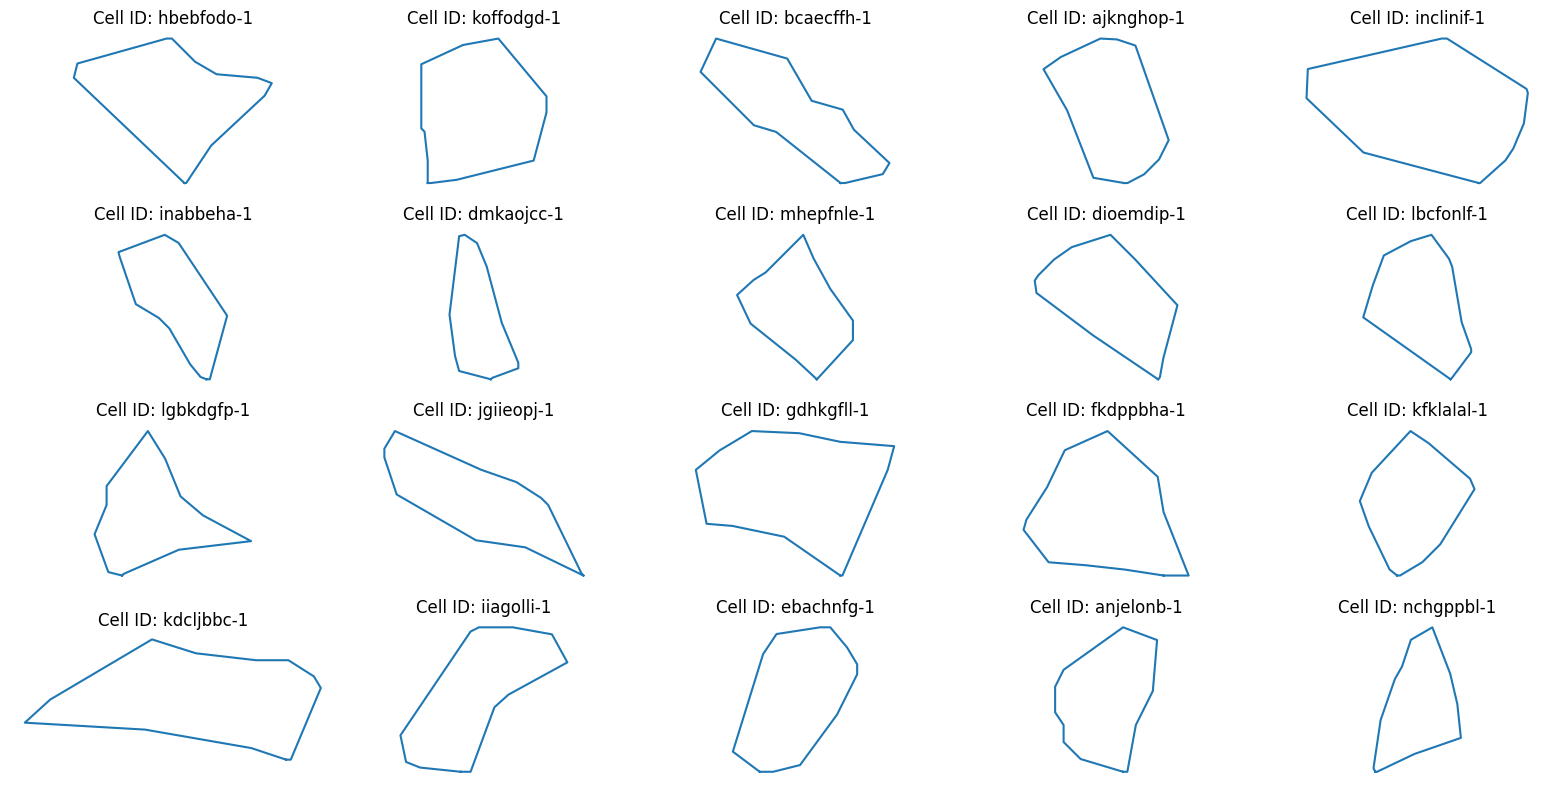

In [18]:
import matplotlib.pyplot as plt
from tic.plotting import plot_cell_boundary
import numpy as np

# random select 20 valid cells from adata.obs_names
cell_ids = np.random.choice(adata.obs_names, size=20, replace=False)

fig, axs = plt.subplots(4, 5, figsize=(16, 8))

for ax, cell_id in zip(axs.flatten(), cell_ids):
    try:
        plot_cell_boundary(adata, cell_id, ax=ax, show=False)
    except ValueError as e:
        ax.set_title(f"Cell {cell_id} (no boundary)")
        ax.axis("off")

plt.tight_layout()
plt.show()

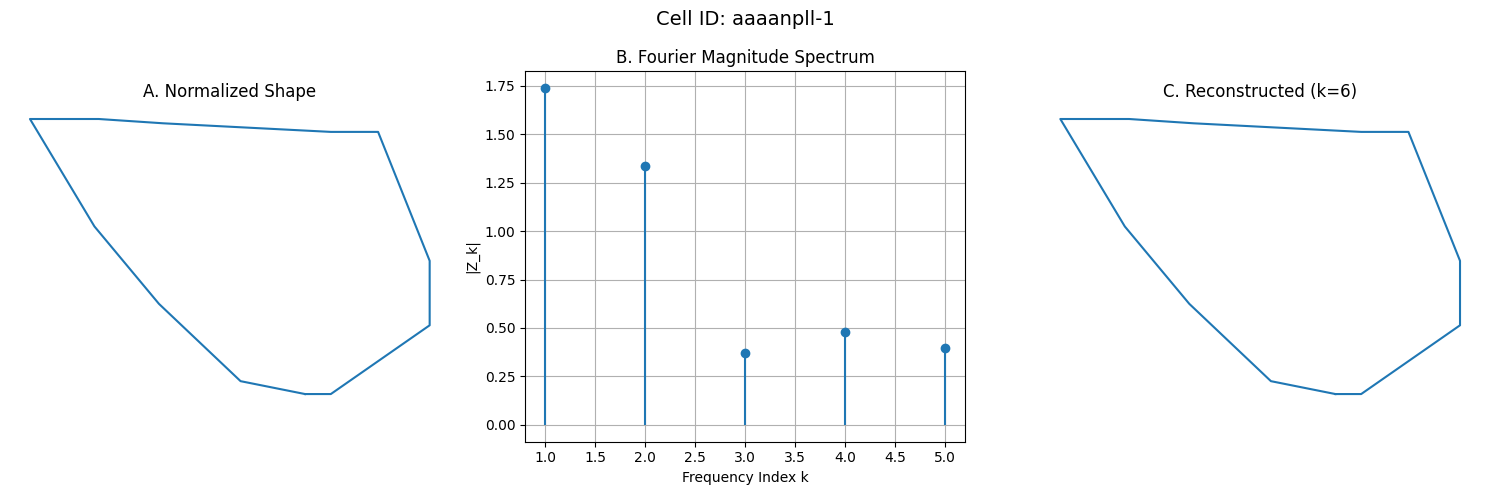

In [19]:
from tic.plotting.geometry import plot_fourier_normalized_shape


plot_fourier_normalized_shape(adata=adata,cell_index=0, n_freq = 6)

In [20]:
from tic.plotting.geometry import generate_fourier_reconstruction_gif


gif_path = generate_fourier_reconstruction_gif(
    adata=adata,          # Your AnnData
    cell_index=0,         # The 0th cell
    ks=[1, 2, 4],         # Custom k sequence (can be omitted for automatic generation,default is 1 to n//2)
    metric="rmse",        # "rmse" | "mae" | Custom callable
    save_path="../media/cell_2_fourier_reconstruction.gif", # Save path
    fps=2                 # 2 frames per second
)

2025-05-29 14:44:04,956 | INFO     | matplotlib.animation | Animation.save using <class 'matplotlib.animation.PillowWriter'>


GIF saved ➜ /Users/zhangjiahao/Test/TIC/media/cell_2_fourier_reconstruction.gif


### Dataset Description
Demonstration of gene expression profiling for FFPE human breast samples on the Xenium platform.
- Pre-designed Xenium Human Breast Gene Expression Panel (v1)
- Custom add-on panel of 100 genes
- Sample types: infiltrating ductal carcinoma, ductal carcinoma in situ, invasive lobular carcinoma
- Protocols: Xenium FFPE Tissue Preparation, Deparaffinization & Decrosslinking, H&E staining and registration.

### Load the cell type annotation if it 


In [21]:
import os
import pandas as pd

# Path to your cell type annotation CSV
csv_path = '../tutorial/example_out/geometry_expr/cell_type_annotation.csv'

if os.path.exists(csv_path):
    # Read CSV
    df = pd.read_csv(csv_path)

    # Ensure the 'cell_id' is the index of the annotation DataFrame
    df.set_index('cell_id', inplace=True)

    # Align and assign cell types only to matching cells in adata
    adata.obs['cell_type'] = adata.obs.index.map(df['pred_cell_type'])

    # Optional: check how many were successfully annotated
    print(f"Annotated {adata.obs['cell_type'].notna().sum()} / {adata.n_obs} cells.")

Annotated 56510 / 56510 cells.


In [22]:
print(adata.obs['cell_type'].unique())  # Inspect annotated cell types

['CD4+ Memory / Naïve T Cells' 'Fibroblasts (Activated/Matrix-producing)'
 'Tissue Macrophages (Tumor-Associated Macrophages, TAMs)'
 'Doublets or Stromal-Leukocyte Mixed Cells' 'Endothelial Cells'
 'Acinar / Tubular Epithelial-like Cells'
 'Negative Controls / Empty Droplets / Artifact' 'B Cells'
 'Plasma Cells (Antibody-Producing B cells)'
 'Fibroblasts / Cancer-Associated Fibroblasts'
 'Smooth Muscle Cells / Myofibroblasts'
 'Migratory Dendritic Cells / Lymphoid Cells (CCR7+)'
 'CD8+ Effector/Activated T Cells'
 'Doublets or Mixed Immune Cells (T cells and Monocytes/Macrophages)'
 'CD8+ Cytotoxic T Cells' 'Natural Killer (NK) Cells'
 'Monocytes / Macrophages (Classical and Non-classical)'
 'Tumor Cells (Papillary Renal Cell Carcinoma - PRCC)'
 'Macrophages (Pro-inflammatory / M2-like)' 'Smooth Muscle Cells'
 'Tumor-Associated Macrophages (Suppressive/Exhausted subset)']


## 2. Annotation Pipeline
Run clustering, marker gene extraction, and LLM-based annotation.
If failed to output the cell type annotation with json format error, just run the following code again.

In [8]:
DATASET_DESCRIPTION = """
This dataset contains spatial transcriptomic data from a formalin-fixed paraffin-embedded (FFPE) section of adult human kidney tumor tissue diagnosed as papillary renal cell carcinoma (PRCC). The data was generated using the Xenium In Situ Gene Expression platform and profiled with the Xenium Human Multi-Tissue and Cancer Panel targeting 377 genes, including markers informative for tumor, immune, stromal, and epithelial cell types.PRCC is a histologically and molecularly distinct subtype of renal cell carcinoma characterized by papillary or tubulopapillary architecture. This tumor type exhibits heterogeneous cellular composition, involving a complex tumor microenvironment (TME).
"""

In [ ]:
from tic.annotation import annotate_adata
from utils.config import API_KEY

# Run the full annotation pipeline
adata_pred, cluster_annotation = annotate_adata(
    adata=adata,
    assign_params={
        'min_cells': 0,
        'min_genes': 0,
        'n_pca': 50,
        'n_neighbors': 15,
        'resolution': 2.0,
        'n_filter_highly_variable_genes': 2000,
    },
    llm_model_name='openai',
    llm_kwargs={'api_key': API_KEY, 'mirror': True},
    dataset_description=DATASET_DESCRIPTION,
    groupby='leiden',
    rank_genes_groups_method='t-test',
    n_genes=10,
    copy=True,
    return_cluster_annotation=True,
)

import json
print(json.dumps(cluster_annotation, indent=2))

### save the cell type annotation as csv file

In [10]:
adata_pred.obs.assign(cell_id=adata_pred.obs_names)[['cell_id', 'pred_cell_type']].to_csv(
    '../tutorial/example_out/geometry_expr/cell_type_annotation.csv', index=False
)

## 3. Visualization of Annotation Results

In [ ]:
import scanpy as sc

# UMAP of Leiden clusters
sc.pl.umap(adata_pred, color=['leiden'], title='Scanpy Leiden Clusters')

# UMAP of LLM-predicted cell types
sc.pl.umap(adata_pred, color=['pred_cell_type'], title='LLM-Predicted Cell Types')

In [ ]:
# Update original AnnData with predicted cell types
adata.obs['cell_type'] = adata_pred.obs['pred_cell_type']
print(adata.obs['cell_type'].unique())

# Count tumor cell populations
tumor_cell_types = []
for ct in adata.obs['cell_type'].unique():
    if 'tumor' in ct.lower():
        print(f"{ct}: {adata[adata.obs['cell_type'] == ct].n_obs} cells")
        tumor_cell_types.append(ct)
print(len(tumor_cell_types))
print(adata.obs['cell_type'].unique())

## 4. Feature Extraction with Geometry Information
Extract features using both gene composition and spatial geometry.

In [23]:
custom_recipe = {
    "geometry_basic": {},
    "fourier_features": {},
    "composition": {"normalize": True},
    "celltype_gene_count": {},
}

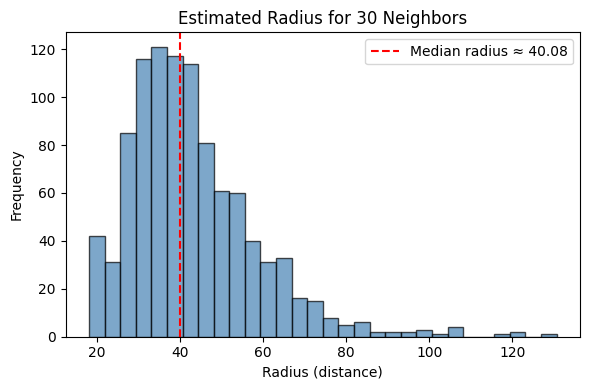

40.07768696739565

In [24]:
from tic.graph import estimate_radius
estimate_radius(adata, n_samples=1000, visualize=True)

In [25]:
from tic.wrappers import FeatureWrapper

fw = FeatureWrapper(
    recipe=custom_recipe,
    centre_types=['Tumor Cells (Papillary Renal Cell Carcinoma - PRCC)'],
    graph_params=None,
    subgraph_params={'strategy':'radius','radius':40},
    build_graph_if_missing=False,
    test_mode=True,
)
fw_adata = fw.fit(adata)
fw_adata

Extracting subgraphs for 1898 cells, cell types:['Tumor Cells (Papillary Renal Cell Carcinoma - PRCC)']: 100%|██████████| 1898/1898 [01:31<00:00, 20.68it/s]
2025-05-29 14:46:01,939 INFO extract_subgraph loop time: 91.759s
2025-05-29 14:46:01,939 | INFO     | tic.features | extract_subgraph loop time: 91.759s


AnnData object with n_obs × n_vars = 1898 × 541
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'feature_modes', 'graph_params', 'subgraph_params', 'X_predictors_names', 'X_predictors_meta'
    obsm: 'geometry_basic', 'fourier_features', 'composition', 'celltype_gene_count', 'X_predictors'

In [26]:
import numpy as np

print('Geometry features shape:', fw_adata.obsm['geometry_basic'].shape)
print('Fourier features shape:', fw_adata.obsm['fourier_features'].shape)
print('NaN fraction (geometry):', np.mean(np.isnan(fw_adata.obsm['geometry_basic'])))
print('NaN fraction (fourier):', np.mean(np.isnan(fw_adata.obsm['fourier_features'])))
print('NaN fraction (composition):', np.mean(np.isnan(fw_adata.obsm['composition'])))

Geometry features shape: (1898, 6)
Fourier features shape: (1898, 10)
NaN fraction (geometry): 0.0
NaN fraction (fourier): 0.0
NaN fraction (composition): 0.0


### Cleaning NaN Entries
Remove cells with any NaN in geometry features and synchronize the AnnData.

In [27]:
valid_geometry = ~np.isnan(fw_adata.obsm['geometry_basic']).any(axis=1)
fw_adata = fw_adata[valid_geometry].copy()
valid_fourier = ~np.isnan(fw_adata.obsm['fourier_features']).any(axis=1)
fw_adata = fw_adata[valid_fourier].copy()
print('Remaining NaN fraction (geometry):', np.mean(np.isnan(fw_adata.obsm['geometry_basic'])))
print('Remaining NaN fraction (fourier):', np.mean(np.isnan(fw_adata.obsm['fourier_features'])))

Remaining NaN fraction (geometry): 0.0
Remaining NaN fraction (fourier): 0.0


## 5. Creating Mixed Features
Concatenate geometry and gene composition features.

In [28]:
geometry = fw_adata.obsm['geometry_basic']
fourier = fw_adata.obsm['fourier_features']
gene_comp = fw_adata.obsm['composition']

fw_adata.obsm['shape+composition'] = np.concatenate([geometry, gene_comp], axis=1)
fw_adata.obsm['fourier+composition'] = np.concatenate([fourier, gene_comp], axis=1)
print('Mixed features shape:', fw_adata.obsm['shape+composition'].shape)
print('Mixed features shape:', fw_adata.obsm['fourier+composition'].shape)

Mixed features shape: (1898, 27)
Mixed features shape: (1898, 31)


## 6. Pseudotime Analysis
Compare pseudotime inference using mixed vs. gene-only features.

2025-05-29 14:46:02,305 | INFO     | tic.pipeline.pseudotime | Pseudotime pipeline order: ['_ClusterStep', '_DRStep', '_PseudotimeStep', '_MetricStep']
100%|██████████| 10/10 [00:03<00:00,  2.75it/s]


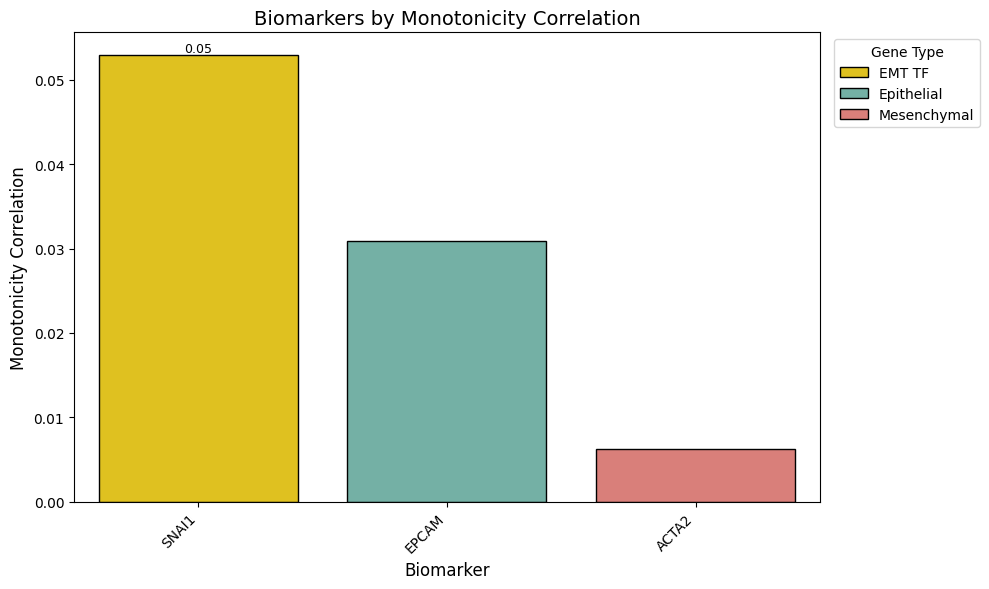

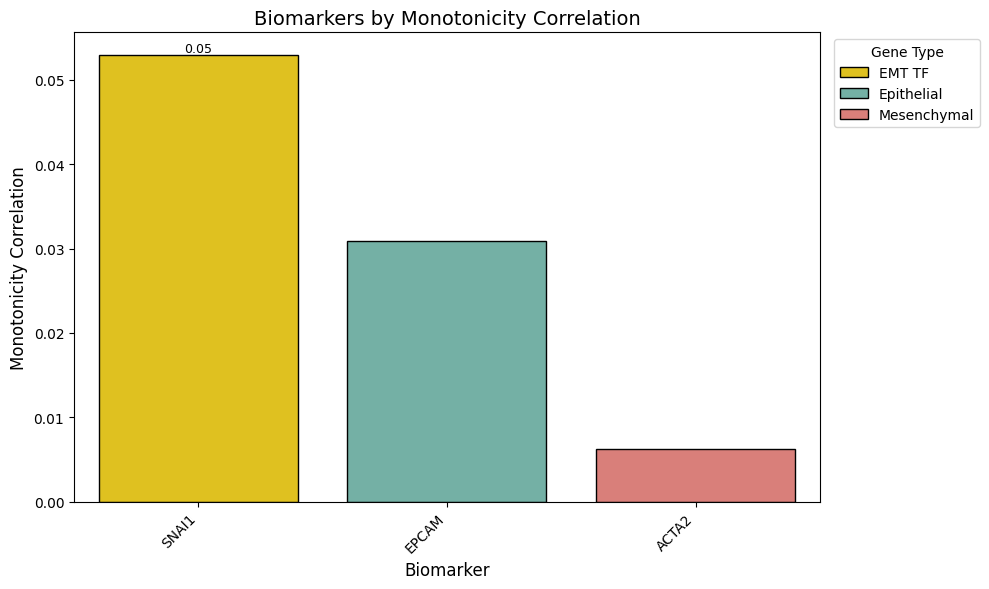

In [29]:
from tic.wrappers import PseudotimeWrapper
from tic.plotting import plot_monotonicity_metrics_bar

# Mixed features pseudotime
pw_mixed = PseudotimeWrapper(rep_key='shape+composition')
pw_mixed.fit(fw_adata)
plot_monotonicity_metrics_bar(metrics=pw_mixed.metrics)

2025-05-29 14:46:10,363 | INFO     | tic.pipeline.pseudotime | Pseudotime pipeline order: ['_ClusterStep', '_DRStep', '_PseudotimeStep', '_MetricStep']
100%|██████████| 10/10 [00:03<00:00,  2.70it/s]


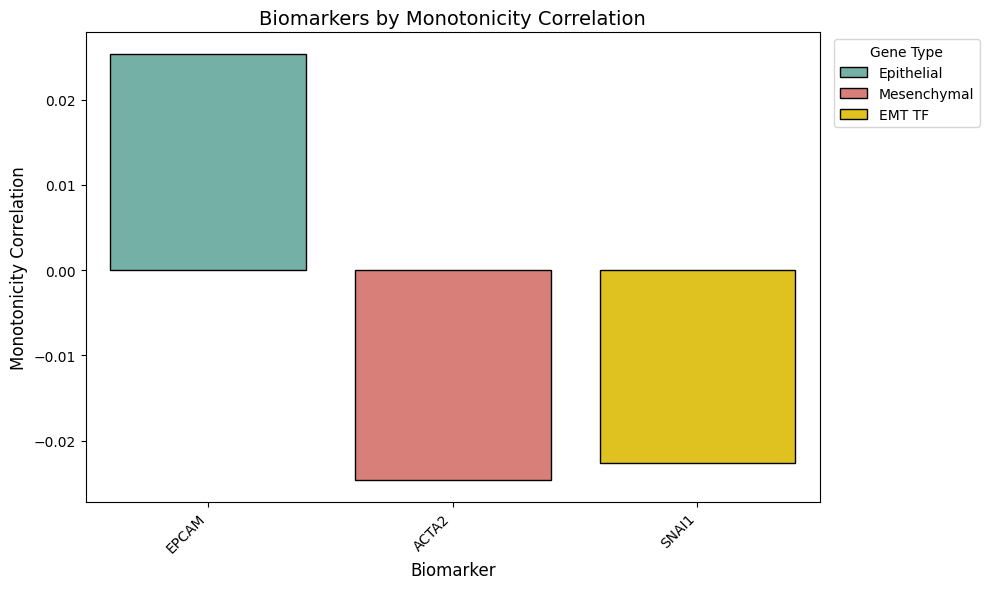

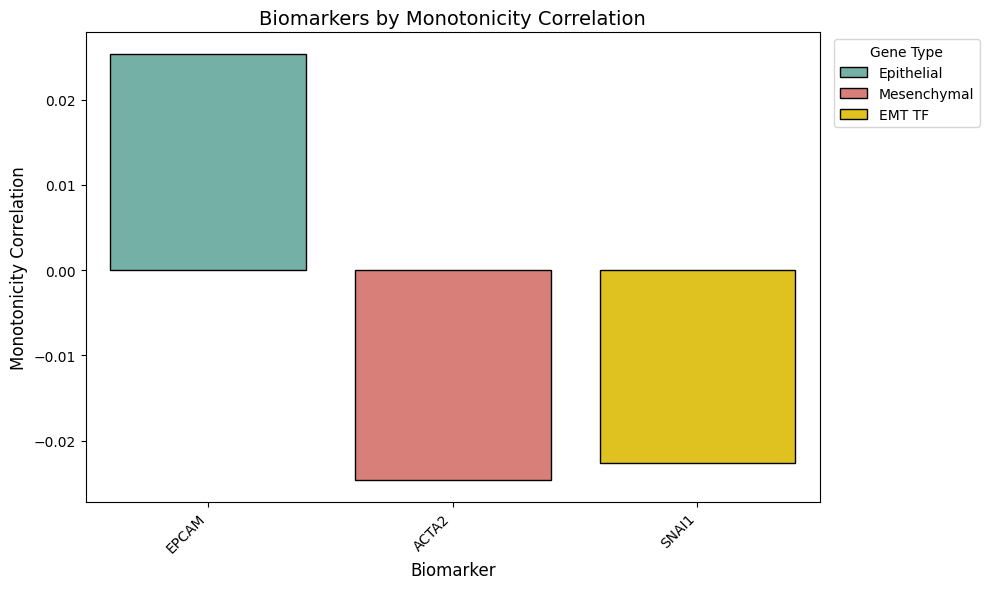

In [30]:
from tic.wrappers import PseudotimeWrapper
from tic.plotting import plot_monotonicity_metrics_bar

# Mixed features pseudotime
pw_fourier = PseudotimeWrapper(rep_key='fourier+composition')
pw_fourier.fit(fw_adata)
plot_monotonicity_metrics_bar(metrics=pw_fourier.metrics)

2025-05-29 14:46:18,462 | INFO     | tic.pipeline.pseudotime | Pseudotime pipeline order: ['_ClusterStep', '_DRStep', '_PseudotimeStep', '_MetricStep']
100%|██████████| 10/10 [00:03<00:00,  2.80it/s]


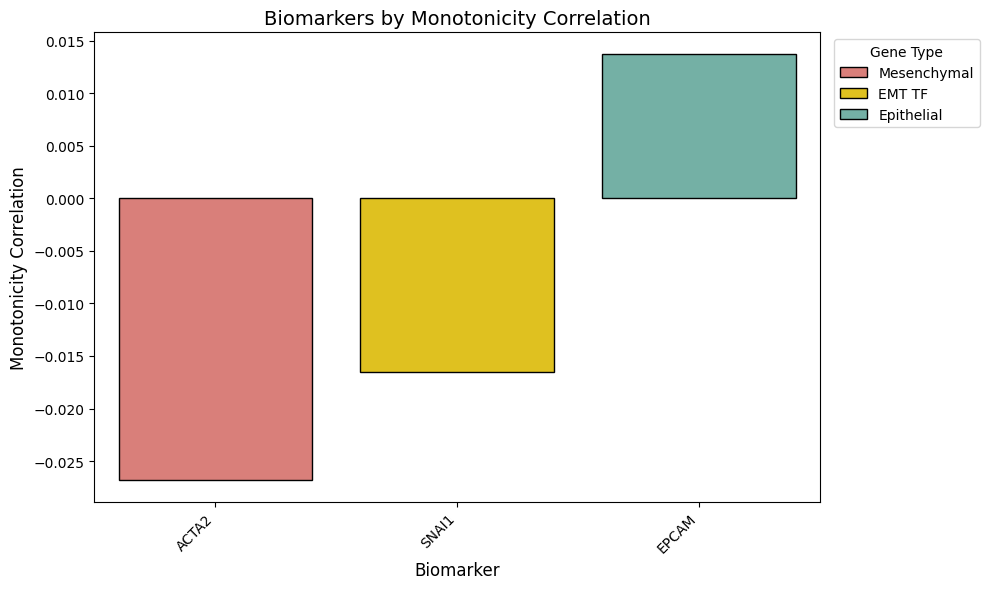

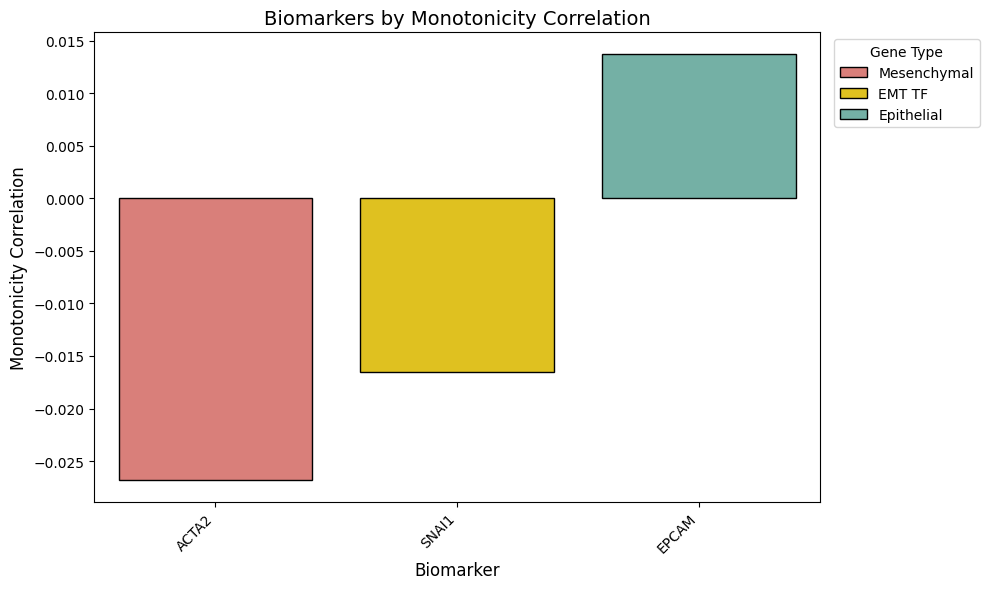

In [31]:
# composition-only features pseudotime
pw_gene = PseudotimeWrapper(rep_key='composition')
pw_gene.fit(fw_adata)
plot_monotonicity_metrics_bar(metrics=pw_gene.metrics)

## 7. Conclusion
Summarize findings: Does including geometry information improve the pseudotime metrics?